# initialize

In [ ]:
from __future__ import print_function

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from PIL import Image
import matplotlib.pyplot as plt

import torchvision.transforms as transforms
import torchvision.models as models
import copy

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# desired size of the output image
imsize = 512 if torch.cuda.is_available() else 128  # use small size if no gpu
imsize = [224,224]
loader = transforms.Compose([
    transforms.Resize(imsize),  # scale imported image
    transforms.ToTensor()])  # transform it into a torch tensor

loader2 = transforms.Compose([
    transforms.Resize(imsize),  # scale imported image
    transforms.Grayscale(),
    transforms.ToTensor()])  # transform it into a torch tensor


def image_loader(image_name,loader):
    image = Image.open(image_name)

    # fake batch dimension required to fit network's input dimensions
    image = loader(image).unsqueeze(0)
    return image.to(device, torch.float)

style_img = image_loader("/content/Style.jpg",loader)
grey_img = image_loader("/content/Style.jpg",loader2)
content_img = image_loader("/content/Content.jpg",loader)

assert style_img.size() == content_img.size(), \
    "we need to import style and content images of the same size"

In [ ]:
style_img.shape

torch.Size([1, 3, 224, 224])

In [ ]:
grey_img.shape
grey_img3 = torch.cat([grey_img] * 3, dim=1)

In [ ]:
grey_img3.shape

torch.Size([1, 3, 224, 224])

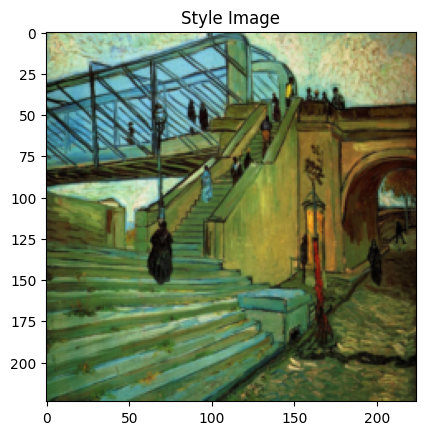

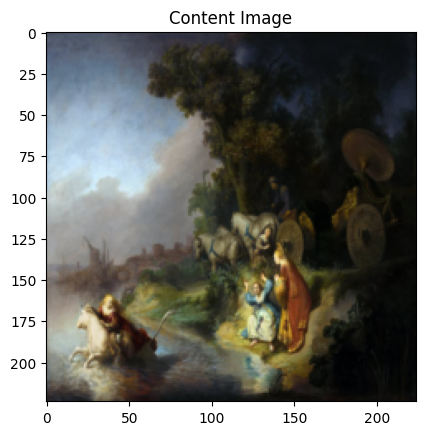

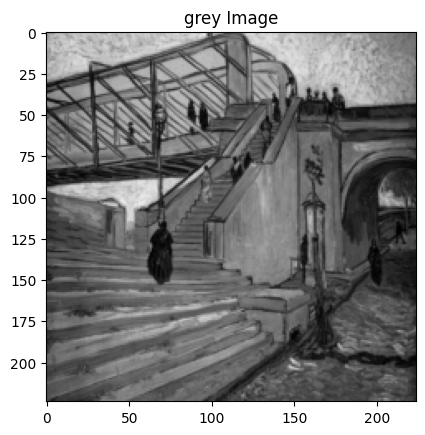

In [ ]:
unloader = transforms.ToPILImage()  # reconvert into PIL image

plt.ion()

def imshow(tensor, title=None):
    image = tensor.cpu().clone()  # we clone the tensor to not do changes on it
    image = image.squeeze(0)      # remove the fake batch dimension
    image = unloader(image)
    plt.imshow(image)
    if title is not None:
        plt.title(title)
    plt.pause(0.001) # pause a bit so that plots are updated


plt.figure()
imshow(style_img, title='Style Image')

plt.figure()
imshow(content_img, title='Content Image')

plt.figure()
imshow(grey_img3, title='grey Image')

In [ ]:
class ContentLoss(nn.Module):

    def __init__(self, target,):
        super(ContentLoss, self).__init__()
        # we 'detach' the target content from the tree used
        # to dynamically compute the gradient: this is a stated value,
        # not a variable. Otherwise the forward method of the criterion
        # will throw an error.
        self.target = target.detach()

    def forward(self, input):
        self.loss = F.mse_loss(input, self.target)
        return input

def gram_matrix(input):
    a, b, c, d = input.size()  # a=batch size(=1)
    # b=number of feature maps
    # (c,d)=dimensions of a f. map (N=c*d)

    features = input.view(a * b, c * d)  # resise F_XL into \hat F_XL

    G = torch.mm(features, features.t())  # compute the gram product

    # we 'normalize' the values of the gram matrix
    # by dividing by the number of element in each feature maps.
    return G.div(a * b * c * d)
    
class StyleLoss(nn.Module):

    def __init__(self, target_feature):
        super(StyleLoss, self).__init__()
        self.target = gram_matrix(target_feature).detach()

    def forward(self, input):
        G = gram_matrix(input)
        self.loss = F.mse_loss(G, self.target)
        return input

import the model

In [ ]:
cnn = models.vgg19(pretrained=True).features.to(device)


/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


In [ ]:
cnn_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
cnn_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)
resnet_normalization_mean = torch.tensor([0.485, 0.456, 0.406]).to(device)
resnet_normalization_std = torch.tensor([0.229, 0.224, 0.225]).to(device)

# create a module to normalize input image so we can easily put it in a
# nn.Sequential
class Normalization(nn.Module):
    def __init__(self, mean, std):
        super(Normalization, self).__init__()
        # .view the mean and std to make them [C x 1 x 1] so that they can
        # directly work with image Tensor of shape [B x C x H x W].
        # B is batch size. C is number of channels. H is height and W is width.
        self.mean = torch.tensor(mean).view(-1, 1, 1)
        self.std = torch.tensor(std).view(-1, 1, 1)

    def forward(self, img):
        # normalize img
        return (img - self.mean) / self.std

#Cnn model

In [ ]:
# desired depth layers to compute style/content losses :
content_layers_default = ['conv_4']
style_layers_default = ['conv_1', 'conv_2', 'conv_3', 'conv_4', 'conv_5']

def get_style_model_and_losses(cnn, normalization_mean, normalization_std,
                               style_img, content_img,
                               content_layers=content_layers_default,
                               style_layers=style_layers_default):
    # normalization module
    normalization = Normalization(normalization_mean, normalization_std).to(device)

    # just in order to have an iterable access to or list of content/syle
    # losses
    content_losses = []
    style_losses = []

    # assuming that cnn is a nn.Sequential, so we make a new nn.Sequential
    # to put in modules that are supposed to be activated sequentially
    model = nn.Sequential(normalization)
    model.to(device)
    i = 0  # increment every time we see a conv
    for layer in cnn.children():
        if isinstance(layer, nn.Conv2d):
            i += 1
            name = 'conv_{}'.format(i)
        elif isinstance(layer, nn.ReLU):
            name = 'relu_{}'.format(i)
            # The in-place version doesn't play very nicely with the ContentLoss
            # and StyleLoss we insert below. So we replace with out-of-place
            # ones here.
            layer = nn.ReLU(inplace=False)
        elif isinstance(layer, nn.MaxPool2d):
            name = 'pool_{}'.format(i)
        elif isinstance(layer, nn.BatchNorm2d):
            name = 'bn_{}'.format(i)
        else:
            raise RuntimeError('Unrecognized layer: {}'.format(layer.__class__.__name__))

        model.add_module(name, layer)

        if name in content_layers:
            # add content loss:
            target = model(content_img).detach()
            content_loss = ContentLoss(target)
            model.add_module("content_loss_{}".format(i), content_loss)
            content_losses.append(content_loss)

        if name in style_layers:
            # add style loss:
            target_feature = model(style_img).detach()
            style_loss = StyleLoss(target_feature)
            model.add_module("style_loss_{}".format(i), style_loss)
            style_losses.append(style_loss)

    # now we trim off the layers after the last content and style losses
    for i in range(len(model) - 1, -1, -1):
        if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
            break

    model = model[:(i + 1)]

    return model, style_losses, content_losses

In [ ]:
input_img = content_img.clone()
# if you want to use white noise instead uncomment the below line:
# input_img = torch.randn(content_img.data.size(), device=device)

# add the original input image to the figure:
plt.figure()
imshow(input_img, title='Input Image')

In [ ]:
def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer = optim.LBFGS([input_img])
    return optimizer

def run_style_transfer_cnn(cnn, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=500,
                       style_weight=10000, content_weight=1):
    """Run the style transfer."""
    print('Building the style transfer model..')
    model, style_losses, content_losses = get_style_model_and_losses(cnn,
        normalization_mean, normalization_std, style_img, content_img)

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    model.requires_grad_(False)

    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            model(input_img)
            style_score = 0
            content_score = 0

            for sl in style_losses:
                style_score += sl.loss
            for cl in content_losses:
                content_score += cl.loss

            style_score *= style_weight
            content_score *= content_weight

            loss = style_score + content_score
            loss.backward()

            run[0] += 1
            if run[0] % 50 == 0:
                print("run {}:".format(run))
                print('Style Loss : {:4f} Content Loss: {:4f}'.format(
                    style_score.item(), content_score.item()))
                print()

            return style_score + content_score

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    return input_img



Building the style transfer model..
Optimizing..


<ipython-input-11-9d0e31e1cc8b>:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
<ipython-input-11-9d0e31e1cc8b>:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


run [50]:
Style Loss : 1.118583 Content Loss: 7.395323

run [100]:
Style Loss : 1.232619 Content Loss: 6.847201

run [150]:
Style Loss : 1.274550 Content Loss: 6.671023

run [200]:
Style Loss : 1.391533 Content Loss: 6.794480

run [250]:
Style Loss : 1.364404 Content Loss: 6.742615

run [300]:
Style Loss : 270820.937500 Content Loss: 475.514252

run [350]:
Style Loss : 4.309826 Content Loss: 16.938246

run [400]:
Style Loss : 1.909164 Content Loss: 8.549688

run [450]:
Style Loss : 1.458695 Content Loss: 7.461573

run [500]:
Style Loss : 1.326119 Content Loss: 7.104359



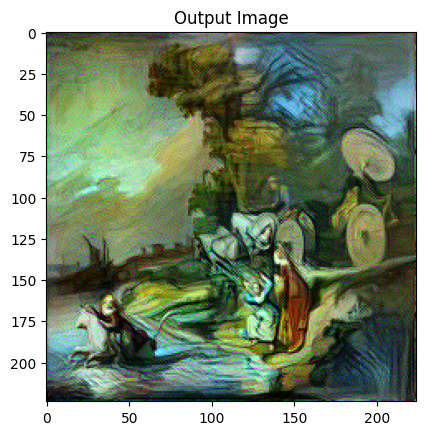

In [ ]:
output = run_style_transfer_cnn(cnn, cnn_normalization_mean, cnn_normalization_std,
                            content_img, style_img, input_img)

plt.figure()
imshow(output, title='Output Image')

# sphinx_gallery_thumbnail_number = 4
plt.ioff()
plt.show()

#Resnet model

In [ ]:
resnet_ori = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
resnet_ori.to(device)

class Resnet(nn.Module):
    def __init__(self):
        super(Resnet,self).__init__()
        normalization = Normalization(resnet_normalization_mean, resnet_normalization_std).to(device)
        self.norm = nn.Sequential(normalization)
        self.model = resnet_ori
    #x holds the input tensor(image) that will be feeded to each layer
    def forward(self,x):
        #initialize an array that wil hold the activations from the chosen layers
        features = []

        x = self.norm(x)
        x = self.model.conv1(x)
        x = self.model.bn1(x)
        x = self.model.relu(x)
        x = self.model.maxpool(x)

        x = self.model.layer1(x)
        features.append(x) 
        x = self.model.layer2(x)
        features.append(x) 
        x = self.model.layer3(x)
        features.append(x) 
        x = self.model.layer4(x)
        features.append(x)  
        return features


def calc_content_loss(gen_feat,orig_feat):
    #calculating the content loss of each layer by calculating the MSE between the content and generated features and adding it to content loss
    # print("gen_feat",len(gen_feat))
    # print("gen_feat",gen_feat[0].shape)
    # print("orig_feat",len(orig_feat))
    # print("orig_feat",orig_feat[0].shape)
    content_l=torch.mean((gen_feat-orig_feat)**2)

    return content_l

    
def calc_style_loss(gen,style):
    #Calculating the gram matrix for the style and the generated image
    batch_size,channel,height,width=gen.shape

    G=torch.mm(gen.view(channel,height*width),gen.view(channel,height*width).t())
    A=torch.mm(style.view(channel,height*width),style.view(channel,height*width).t())
        
    #Calcultating the style loss of each layer by calculating the MSE between the gram matrix of the style image and the generated image and adding it to style loss
    style_l=torch.mean((G-A)**2)
    return style_l



def calculate_loss(gen_features, orig_feautes, style_featues,grey_features,style_weight,content_weight,grey_weight):
    style_loss=content_loss=grey_loss = 0
    length = len(gen_features)
    i = 0
    for gen,cont,style,grey in zip(gen_features,orig_feautes,style_featues,grey_features):
        #extracting the dimensions from the generated image
        if(i == length-1):
          content_loss+=calc_content_loss(gen,cont)

        style_loss+=calc_style_loss(gen,style)
        grey_loss += calc_style_loss(gen,grey)
        i = i + 1
    
    #calculating the total loss of e th epoch
    total_loss=content_weight*content_loss + style_weight*style_loss  + grey_loss*grey_weight
    return total_loss, content_weight*content_loss, style_weight*style_loss, grey_loss*grey_weight

Using cache found in /root/.cache/torch/hub/pytorch_vision_v0.10.0
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


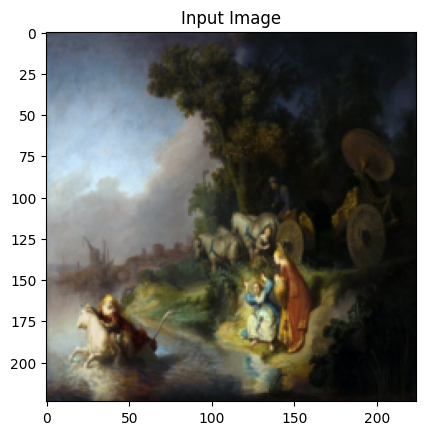

In [ ]:
content_w = [1e2, 1e4, 1e6]
style_w = [1e-4, 1e-2, 1]


input_img = content_img.clone()
# if you want to use white noise instead uncomment the below line:
# input_img = torch.randn(content_img.data.size(), device=device)

# add the original input image to the figure:
plt.figure()
imshow(input_img, title='Input Image')

In [ ]:
style_img.shape

torch.Size([1, 3, 224, 224])

<ipython-input-29-c0fc91bfa235>:14: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.mean = torch.tensor(mean).view(-1, 1, 1)
<ipython-input-29-c0fc91bfa235>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.std = torch.tensor(std).view(-1, 1, 1)


Building the style transfer model..
Optimizing..
run [100]:
total Loss : 111.611008 

run [200]:
total Loss : 85.518471 

run [300]:
total Loss : 74.028343 

run [400]:
total Loss : 68.091354 

run [500]:
total Loss : 63.700001 

run [600]:
total Loss : 60.399223 

run [700]:
total Loss : 58.978798 

run [800]:
total Loss : 56.615692 

run [900]:
total Loss : 55.456638 

run [1000]:
total Loss : 54.982193 

run [1100]:
total Loss : 53.558689 

run [1200]:
total Loss : 53.012928 



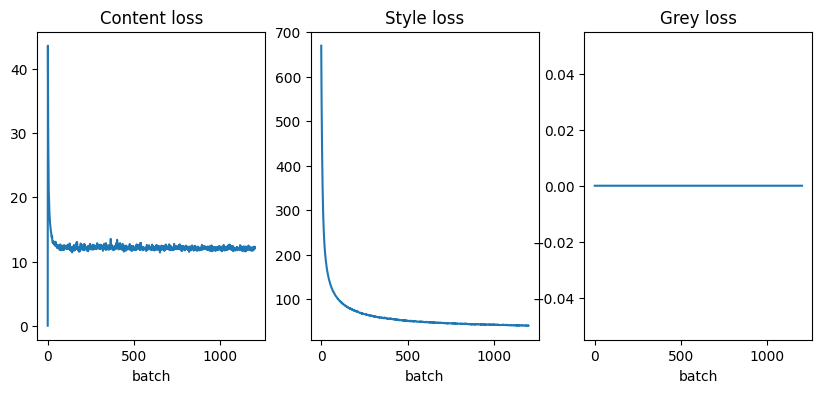

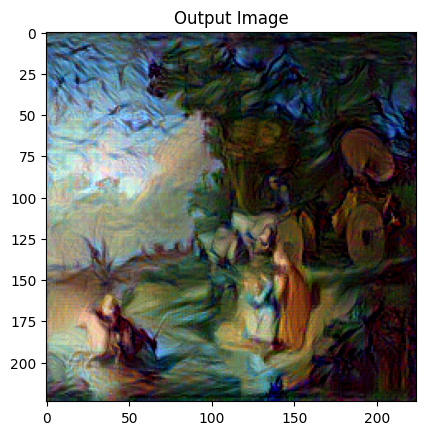

In [ ]:
from torchvision.utils import save_image
resnet = Resnet().to(device)

def get_input_optimizer(input_img):
    # this line to show that input is a parameter that requires a gradient
    optimizer=optim.Adam([input_img],lr=0.0025)
    return optimizer
loss_C = []
loss_S = []
loss_G = []
def run_style_transfer_resnet(model, normalization_mean, normalization_std,
                       content_img, style_img, input_img, num_steps=1000,
                       style_weight=100, content_weight=0.01, grey_weight=0.01):
    """Run the style transfer."""
    print('Building the style transfer model..')

    # We want to optimize the input and not the model parameters so we
    # update all the requires_grad fields accordingly
    input_img.requires_grad_(True)
    model.requires_grad_(False)
    optimizer = get_input_optimizer(input_img)

    print('Optimizing..')
    run = [0]
    
    while run[0] <= num_steps:

        def closure():
            # correct the values of updated input image
            with torch.no_grad():
                input_img.clamp_(0, 1)

            optimizer.zero_grad()
            gen_features=model(input_img)
            orig_feautes=model(content_img)
            style_featues=model(style_img)
            grey_features = model(grey_img3)
            total_loss, loss_con, loss_sty, loss_gr=calculate_loss(gen_features, orig_feautes, style_featues,grey_features, style_weight,content_weight, grey_weight)
            loss_C.append(loss_con.item())
            loss_S.append(loss_sty.item())
            loss_G.append(loss_gr.item())
            total_loss.backward()

            run[0] += 1
            if run[0] % 100 == 0:
                print("run {}:".format(run))
                print('total Loss : {:4f} '.format(
                     total_loss.item()))
                print()

            return total_loss

        optimizer.step(closure)

    # a last correction...
    with torch.no_grad():
        input_img.clamp_(0, 1)

    # VISUALIZE HERE
    _, loss = plt.subplots(1, 3, figsize=(10, 4))
    loss[0].plot(loss_C)
    loss[0].set_title("Content loss")
    loss[0].set_xlabel("batch")
    loss[1].plot(loss_S)
    loss[1].set_title("Style loss")
    loss[1].set_xlabel("batch")
    loss[2].plot(loss_G)
    loss[2].set_title("Grey loss")
    loss[2].set_xlabel("batch")
    plt.show()  

    return input_img



# content_w = [1e2, 1e4, 1e6]
# style_w = 5*[1e-4, 1e-2, 1]

content_w = [1e2]
style_w = [1]
for i in content_w:
  for j in style_w:
    input_img = content_img.clone()
    output = run_style_transfer_resnet(resnet, resnet_normalization_mean, resnet_normalization_std,
                                content_img, style_img, input_img, 1200,
                       style_weight=j, content_weight=i, grey_weight=0)

    plt.figure()
    imshow(output, title='Output Image')

    # sphinx_gallery_thumbnail_number = 4
    plt.ioff()
    plt.show()
    save_image(output,"/content/gen"+"content_w" + str(i) + "_style_w" + str(j)  +".png")


In [ ]:
loss_C

[0.0,
 29.013460159301758,
 22.85904884338379,
 19.146268844604492,
 17.451126098632812,
 16.28727149963379,
 15.167691230773926,
 15.290078163146973,
 15.027950286865234,
 15.052398681640625,
 14.473687171936035,
 14.349100112915039,
 14.496920585632324,
 14.706584930419922,
 14.768232345581055,
 14.649250984191895,
 14.84367561340332,
 14.893145561218262,
 14.822607040405273,
 14.83130931854248,
 14.748893737792969,
 14.678319931030273,
 14.778794288635254,
 14.894493103027344,
 14.797412872314453,
 14.842973709106445,
 14.721512794494629,
 14.693878173828125,
 14.646856307983398,
 14.693305015563965,
 14.703336715698242,
 14.645356178283691,
 14.529644012451172,
 14.455512046813965,
 14.461588859558105,
 14.491945266723633,
 14.35409164428711,
 14.352499008178711,
 14.49007797241211,
 14.578095436096191,
 14.535601615905762,
 14.525360107421875,
 14.441822052001953,
 14.564579963684082,
 14.396140098571777,
 14.247909545898438,
 14.21988296508789,
 14.294401168823242,
 14.4416284561

In [ ]:
loss_S

[0.0,
 669.4251098632812,
 287.76434326171875,
 0.40371665358543396,
 666.3990478515625,
 286.17791748046875,
 1.0026746988296509,
 663.7273559570312,
 284.7948303222656,
 1.4974905252456665,
 661.3099975585938,
 283.5560302734375,
 1.8742008209228516,
 659.0567016601562,
 282.4110107421875,
 2.1598808765411377,
 656.9004516601562,
 281.32489013671875,
 2.3850178718566895,
 654.8119506835938,
 280.2825927734375,
 2.585493803024292,
 652.7738037109375,
 279.2773132324219,
 2.7654104232788086,
 650.7693481445312,
 278.2927551269531,
 2.9219284057617188,
 648.7948608398438,
 277.3274230957031,
 3.049776792526245,
 646.86767578125,
 276.38861083984375,
 3.154778480529785,
 644.9823608398438,
 275.4709777832031,
 3.237917900085449,
 643.1248779296875,
 274.566650390625,
 3.3111274242401123,
 641.2858276367188,
 273.6705322265625,
 3.3948354721069336,
 639.4603271484375,
 272.78326416015625,
 3.483191967010498,
 637.6458740234375,
 271.9027099609375,
 3.5721607208251953,
 635.8430786132812,


In [ ]:
# resnet = torch.hub.load('pytorch/vision:v0.10.0', 'resnet50', pretrained=True)
# resnet.to(device)

# def get_style_model_and_losses_resnet(resnet, normalization_mean, normalization_std,
#                                style_img, content_img):

#   # normalization module
#   normalization = Normalization(resnet_normalization_mean, resnet_normalization_std).to(device)

#   # just in order to have an iterable access to or list of content/syle
#   # losses
#   content_losses = []
#   style_losses = []

#   # assuming that cnn is a nn.Sequential, so we make a new nn.Sequential
#   # to put in modules that are supposed to be activated sequentially
#   model = nn.Sequential(normalization)
#   model.to(device)
#   i = 0  # increment every time we see a conv

#   def helper(layers):
#     global i
#     temp = nn.Sequential()
#     for index, layer in list(layers.named_children()):
#         print('-----------------------------')
#         print(index)

#         if isinstance(layer, nn.Conv2d):
#             i += 1
#             name = 'conv_{}'.format(i)
#             temp = nn.Sequential()
#             temp.add_module(name, layer)
#             target = model(content_img).detach()
#             content_loss = ContentLoss(target)
#             temp.add_module("content_loss_{}".format(i), content_loss)
#             content_losses.append(content_loss)

#             setattr(layers, index, temp)
#         elif isinstance(layer, nn.ReLU):
#             name = 'relu_{}'.format(i)
#             # The in-place version doesn't play very nicely with the ContentLoss
#             # and StyleLoss we insert below. So we replace with out-of-place
#             # ones here.
#             layer = nn.ReLU(inplace=False)
#         elif isinstance(layer, nn.MaxPool2d):
#             name = 'pool_{}'.format(i)
#         elif isinstance(layer, nn.BatchNorm2d):
#             name = 'bn_{}'.format(i)
#         else:
#             layer = helper(layer)


#   for index,layer in list(resnet.named_children()):
#     print('-----------------------------')
#     print(index)
#     print(layer)
#     if isinstance(layer, nn.Conv2d):
#         i += 1
#         name = 'conv_{}'.format(i)
#         temp = nn.Sequential()
#         temp.add_module(name, layer)
#         target = model(content_img).detach()
#         content_loss = ContentLoss(target)
#         temp.add_module("content_loss_{}".format(i), content_loss)
#         content_losses.append(content_loss)
#         setattr(resnet, index, temp)

#     elif isinstance(layer, nn.ReLU):
#         name = 'relu_{}'.format(i)
#         # The in-place version doesn't play very nicely with the ContentLoss
#         # and StyleLoss we insert below. So we replace with out-of-place
#         # ones here.
#         layer = nn.ReLU(inplace=False)
#     elif isinstance(layer, nn.MaxPool2d):
#         name = 'pool_{}'.format(i)
#     elif isinstance(layer, nn.BatchNorm2d):
#         name = 'bn_{}'.format(i)
#     else:
#         layer = helper(layer)

#   # now we trim off the layers after the last content and style losses
#   # for i in range(len(model) - 1, -1, -1):
#   #     if isinstance(model[i], ContentLoss) or isinstance(model[i], StyleLoss):
#   #         break

#   # model = model[:(i + 1)]

#   return model, style_losses, content_losses